In [5]:
import pandas as pd # type: ignore
from datetime import datetime
from env import DiscreteEnv
import numpy as np # type: ignore
import matplotlib.pyplot as plt # type: ignore


c:\Users\aleja\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated and will be removed in a future release
  "class": algorithms.Blowfish,


PyBaMM can collect usage data and send it to the PyBaMM team to help us improve the software.
We do not collect any sensitive information such as models, parameters, or simulation results - only information on which parts of the code are being used and how frequently.
This is entirely optional and does not impact the functionality of PyBaMM.
For more information, see https://docs.pybamm.org/en/latest/source/user_guide/index.html#telemetry

Timeout reached. Defaulting to not enabling telemetry.


In [6]:
df = pd.read_csv("../data/20241121-20251121 CAISO Real-time Price.csv") # for training
df = df[df.hub == "TH_SP15"].reset_index(drop=True)
df.Date = [datetime.strptime(date.strip("'"), "%m/%d/%Y %I:%M:%S %p") for date in df.Date]
df_quarterhr = df.iloc[[i for i in range(len(df.Date)) if df.Date.iloc[i].minute in [0, 15, 30, 45]]]

df2 = pd.read_csv("../data/20231121-20241121 CAISO Real-time Price.csv") # for testing
df2 = df2[df2.hub == "TH_SP15"].reset_index(drop=True)
df2.Date = [datetime.strptime(date.strip("'"), "%m/%d/%Y %I:%M:%S %p") for date in df2.Date]
df2_quarterhr = df2.iloc[[i for i in range(len(df2.Date)) if df2.Date.iloc[i].minute in [0, 15, 30, 45]]]

In [26]:
df2_quarterhr.tail()

,Date,price,hub
105500,2024-11-21 22:45:00,49.48739,TH_SP15
105503,2024-11-21 23:00:00,53.37058,TH_SP15
105506,2024-11-21 23:15:00,50.44888,TH_SP15
105509,2024-11-21 23:30:00,48.91468,TH_SP15
105512,2024-11-21 23:45:00,45.73838,TH_SP15


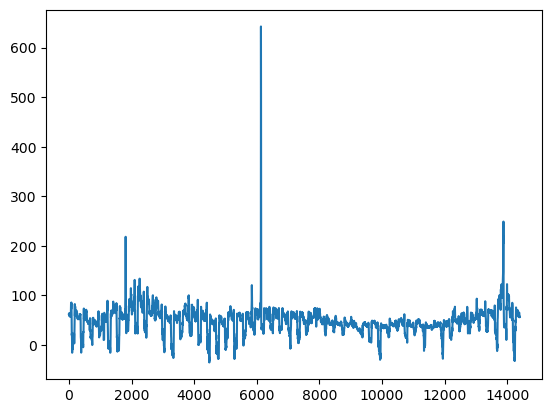

In [14]:
plt.figure()
plt.plot(df2_quarterhr.price.iloc[0:4*24*50])

In [31]:
df3 = pd.read_csv("../forecasters_replication/caiso_sp15_cnn3_forecast_nov2024-nov2025.csv")
df3["Date"]=df3["datetime"].apply(lambda x: datetime.strptime(x, "%Y-%m-%d %H:%M:%S"))
df3.sample(5)

,datetime,price,forecast_price_cnn3,Date
6972,2025-09-09 08:00:00,7.853899,17.403810,2025-09-09 08:00:00
2667,2025-03-13 23:00:00,58.225480,44.759537,2025-03-13 23:00:00
3138,2025-04-02 14:00:00,-19.133347,2.182822,2025-04-02 14:00:00
6767,2025-08-31 19:00:00,45.466152,51.703693,2025-08-31 19:00:00
5616,2025-07-14 20:00:00,43.861572,59.344913,2025-07-14 20:00:00


In [32]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8732 entries, 0 to 8731
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   datetime             8732 non-null   object        
 1   price                8732 non-null   float64       
 2   forecast_price_cnn3  8732 non-null   float64       
 3   Date                 8732 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 273.0+ KB


<Axes: xlabel='Date'>

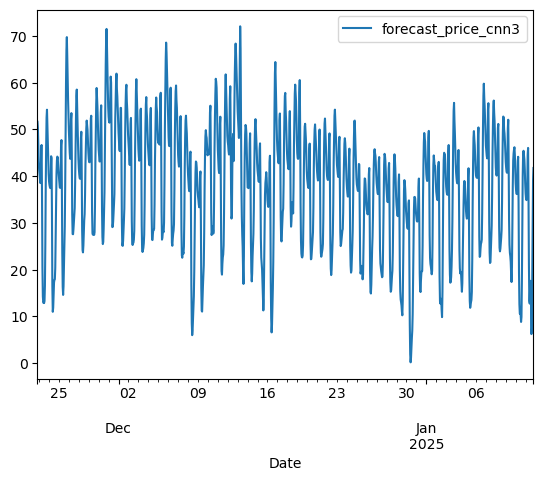

In [34]:
df3.iloc[:24*50].plot(x="Date", y="forecast_price_cnn3")

In [57]:
# mean df3.price by hour of the day
df3["h"]=df3.Date.dt.hour
df3.groupby(["h"]).price.mean()
#spread 36
36*180*10 #USD in 6 months

64800

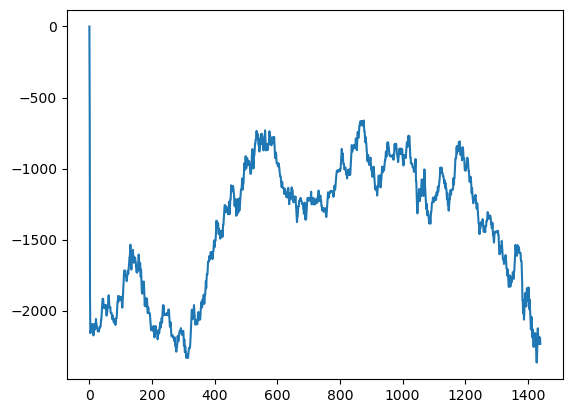

In [ ]:

env = DiscreteEnv(24*60, df3)
state, info = env.reset()
done = False
cum_rew = [0]
soc = [0]

while not done:
    action = env.action_space.sample() # random baseline
    state, reward, done, _, info = env.step(action)
    cum_rew.append(cum_rew[-1]+reward)
    soc.append(state[0])
    
plt.figure()
plt.plot(range(len(cum_rew)), cum_rew)
#plt.plot(range(len(soc)), soc)

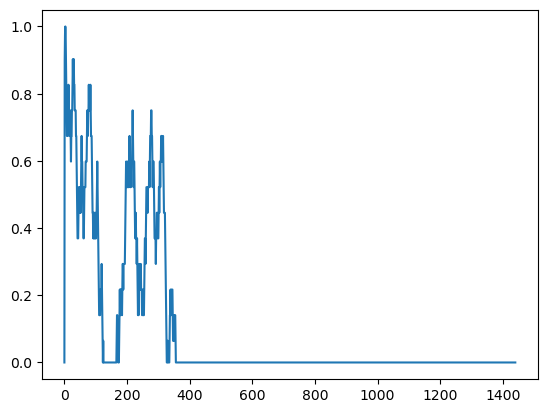

In [67]:
plt.plot(range(len(soc)), soc)

In [52]:
# DQN PARAMS
RL_PARAMS = {
    'policy': "MlpPolicy",
    # 'learning_rate': 0.00176746728919149,  # Default: 1e-4
    'learning_rate': 1e-4,
    'buffer_size': 100_000,  # Default: 1e6
    'learning_starts': 255,  # Default: 50_000
    'batch_size': 256,  # Default: 32
    'tau': 0.5016120493544259,  # Default: 1.0
    'gamma': 0.9999812912592504,  # Default: 0.99
    'train_freq': 84,  # Default: 4
    'gradient_steps': -1,  # Default: 1
    'target_update_interval': 10_000,  # Default: 1e4
    'exploration_fraction': 0.5,  # Default: 0.1
    'exploration_initial_eps': 1.0,  # Default: 1.0
    'exploration_final_eps': 0.005,  # Default: 0.05
    'max_grad_norm': 3.266151433390378,  # Default: 10

    'policy_kwargs': {
        # Defaults reported for MultiInputPolicy
        'net_arch': 'extra_large',  # Default: None
        'activation_fn': 'leaky_relu',  # Default: tanh
    }
}

In [74]:
import os
import time
import json
from typing import Optional

from stable_baselines3 import PPO, SAC, DDPG, DQN, A2C #type: ignore
from stable_baselines3.common.callbacks import EvalCallback #type: ignore
from stable_baselines3.common.evaluation import evaluate_policy #type: ignore
from stable_baselines3.common.logger import configure #type: ignore

"""
    Trains a reinforcement learning agent.

    :param agent: A string that represents the name of the reinforcement learning agent.
    :param run: An integer that represents the run number.
    :param path: A string that represents the path to the directory where the data will be saved.
    :param exp_params: A dictionary that contains the experiment parameters.
    :param env_id: A string that represents the ID of the environment.
    :param env_kwargs: A dictionary that contains the keyword arguments for the environment.
    :param rl_params: A dictionary that contains the reinforcement learning parameters.
    :param verbose: An integer that represents the verbosity level.
    :param discrete_actions: A list of discrete actions.
    :param logger_type: A list that represents the logger type.
"""

start = time.time()

# CREATE ENVIRONMENT
env = DiscreteEnv(24*180, df3)
    
model = DQN("MlpPolicy", env, verbose=1)
model.learn(total_timesteps=10000, log_interval=4)

eval_env = DiscreteEnv(24*360, df3) 
mean_reward, std_reward = evaluate_policy(model, eval_env, n_eval_episodes=10)

print(f"mean_reward: {mean_reward:.2f} +/- {std_reward:.2f}")

env.close()

print()
print(f'Execution time = {time.time() - start}s')

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
mean_reward: 299137.69 +/- 1153.06

Execution time = 46.91322708129883s


In [73]:
180*10*36

64800

Total profit on this slice: -192.44
Average reward per step: -1.1523
Action counts (index 0=-1MW,1=0MW,2=+1MW):
action_idx
0     44
1      1
2    122
Name: count, dtype: int64


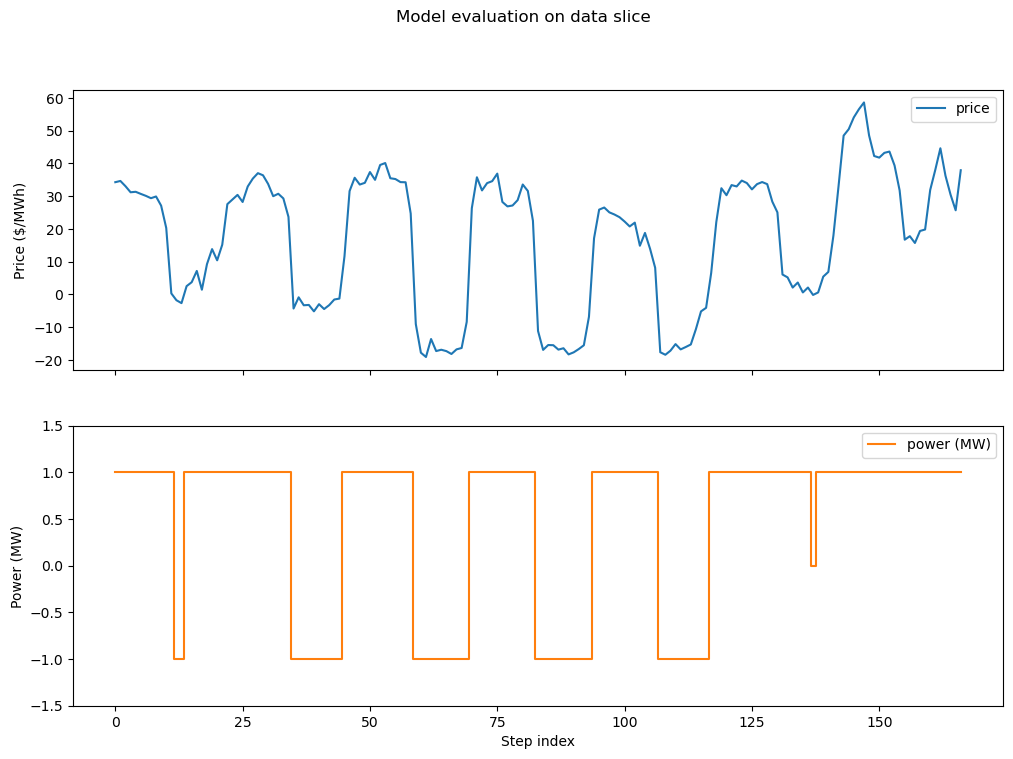

In [81]:
# Imports (if not already present)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Helper to evaluate over a slice
def evaluate_on_slice(model, dataframe, start_idx=0, length=None, deterministic=True):
    """
    Run the trained model on the specified slice and return a pandas DataFrame log.
    - model: a stable-baselines3 vector/model (e.g., DQN object).
    - dataframe: DataFrame used by env; must contain a `price` column & Date column if you want to use it
    - start_idx: index of dataframe to start
    - length: number of rows in slice (if None, use from start_idx to end)
    - deterministic: model.predict deterministic flag
    """
    df_slice = dataframe.reset_index(drop=True)
    if length is not None:
        df_slice = df_slice.iloc[start_idx:start_idx+length].reset_index(drop=True)
    else:
        df_slice = df_slice.iloc[start_idx:].reset_index(drop=True)

    n_steps = max(len(df_slice) - 1, 1)
    env = DiscreteEnv(n_steps, df_slice)

    # Reset env then force a deterministic start (index 0)
    obs, info = env.reset()
    # override random start
    env.init_index = 0
    env.count = 0
    env.battery.reset()  # initialize battery sim deterministically
    env.battery_state = env.battery._get_current_state()
    env.state = [env.battery_state["physics"]["soc"], df_slice.iloc[0].price]
    env.cum_reward = 0.0

    logs = []
    action_list = [-1, 0, 1]
    state = obs  # state = [soc, price] initially
    step = 0
    while True:
        # Model action
        action, _ = model.predict(state, deterministic=deterministic)
        # Convert to python int if returned as np array/np type
        action = int(np.array(action).item()) if np.ndim(action) > 0 else int(action)

        # Save pre-step details
        cur_soc = float(state[0])
        cur_price = float(state[1])

        # Step
        next_state, reward, done, truncated, _ = env.step(action)

        logs.append({
            "step": step,
            "index": env.init_index + env.count - 1 if env.count > 0 else env.init_index,
            "timestamp": df_slice.iloc[env.count + env.init_index].Date if 'Date' in df_slice.columns else None,
            "price": cur_price,
            "action_idx": action,
            "power_mw": action_list[action],   # -1, 0, 1
            "soc": cur_soc,
            "reward": float(reward),
            "cum_reward": float(env.cum_reward)
        })

        state = next_state
        step += 1
        if done or truncated:
            break

    return pd.DataFrame(logs)


# Example usage:
# 1) choose a time slice (by index or date)
# Example: slice by index for one day (assuming 15min timesteps -> 96 per day). Use your own length/time units:
slice_start = 24*180
slice_len = 24*7 # adjust as needed

df_slice = df3.iloc[slice_start:slice_start + slice_len].reset_index(drop=True)

# 2) run the model on that slice
logs = evaluate_on_slice(model, df3, start_idx=slice_start, length=slice_len, deterministic=True)

# 3) quick summary metrics
total_profit = logs['reward'].sum()
avg_reward = logs['reward'].mean()
action_counts = logs['action_idx'].value_counts().sort_index()
print("Total profit on this slice:", round(total_profit, 2))
print("Average reward per step:", round(avg_reward, 4))
print("Action counts (index 0=-1MW,1=0MW,2=+1MW):")
print(action_counts)

# 4) plotting (price, soc, and actions)
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axs[0].plot(logs['price'], label='price', color='C0')
axs[0].set_ylabel('Price ($/MWh)')
axs[0].legend()

# Plot discrete actions scaled for readability
axs[1].step(logs.index, logs['power_mw'], label='power (MW)', where='mid', color='C1')
axs[1].set_ylabel('Power (MW)')
axs[1].set_ylim(-1.5, 1.5)
axs[1].legend()

plt.xlabel('Step index')
plt.suptitle('Model evaluation on data slice')
plt.show()

In [82]:
logs

,step,index,timestamp,price,action_idx,power_mw,soc,reward,cum_reward
0,0,0,2025-05-21 21:00:00,34.253070,2,1,0.000000,-608.976299,-608.976299
1,1,1,2025-05-21 22:00:00,34.628610,2,1,0.900000,-693.969484,-1302.945783
2,2,2,2025-05-21 23:00:00,33.024650,2,1,0.821507,-706.399153,-2009.344935
3,3,3,2025-05-22 00:00:00,31.176662,2,1,0.742243,-605.262300,-2614.607235
4,4,4,2025-05-22 01:00:00,31.321785,2,1,0.661546,-295.805838,-2910.413073
...,...,...,...,...,...,...,...,...,...
162,162,162,2025-05-28 15:00:00,44.613390,2,1,0.000000,44.439440,-322.168974
163,163,163,2025-05-28 16:00:00,36.225426,2,1,0.000000,36.084181,-286.084793
164,164,164,2025-05-28 17:00:00,30.434656,2,1,0.000000,30.315989,-255.768804
165,165,165,2025-05-28 18:00:00,25.674297,2,1,0.000000,25.574191,-230.194612


## entest2

In [86]:
import os
import time
import json
from typing import Optional

from stable_baselines3 import PPO, SAC, DDPG, DQN, A2C #type: ignore
from stable_baselines3.common.callbacks import EvalCallback #type: ignore
from stable_baselines3.common.evaluation import evaluate_policy #type: ignore
from stable_baselines3.common.logger import configure #type: ignore

"""
    Trains a reinforcement learning agent.

    :param agent: A string that represents the name of the reinforcement learning agent.
    :param run: An integer that represents the run number.
    :param path: A string that represents the path to the directory where the data will be saved.
    :param exp_params: A dictionary that contains the experiment parameters.
    :param env_id: A string that represents the ID of the environment.
    :param env_kwargs: A dictionary that contains the keyword arguments for the environment.
    :param rl_params: A dictionary that contains the reinforcement learning parameters.
    :param verbose: An integer that represents the verbosity level.
    :param discrete_actions: A list of discrete actions.
    :param logger_type: A list that represents the logger type.
"""

start = time.time()

# CREATE ENVIRONMENT
env = DiscreteEnv(8760, df_quarterhr)
    
model = DQN("MlpPolicy", env, verbose=1)
model.learn(total_timesteps=10000, log_interval=4)

eval_env = DiscreteEnv(8760*4, df2_quarterhr) # corresponds to 8760 hours from the og paper
mean_reward, std_reward = evaluate_policy(model, eval_env, n_eval_episodes=10)

print(f"mean_reward: {mean_reward:.2f} +/- {std_reward:.2f}")

env.close()

print()
print(f'Execution time = {time.time() - start}s')

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
mean_reward: 320546.28 +/- 1192.12

Execution time = 322.0353000164032s


Total profit on this slice: 13029.51
Average reward per step: 9.7018
Action counts (index 0=-1MW,1=0MW,2=+1MW):
action_idx
0      75
2    1268
Name: count, dtype: int64


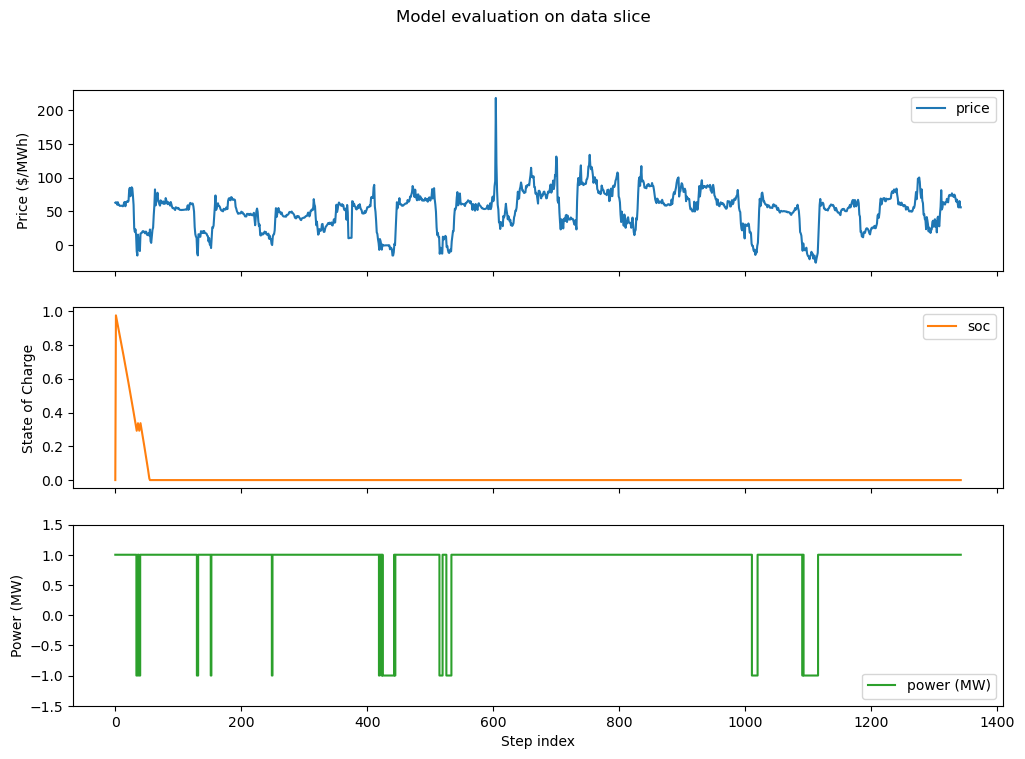

In [92]:
slice_start = 0
slice_len = 24*14*4

df_slice = df2_quarterhr.iloc[slice_start:slice_start + slice_len].reset_index(drop=True)

# 2) run the model on that slice
logs = evaluate_on_slice(model, df2_quarterhr, start_idx=slice_start, length=slice_len, deterministic=True)

# 3) quick summary metrics
total_profit = logs['reward'].sum()
avg_reward = logs['reward'].mean()
action_counts = logs['action_idx'].value_counts().sort_index()
print("Total profit on this slice:", round(total_profit, 2))
print("Average reward per step:", round(avg_reward, 4))
print("Action counts (index 0=-1MW,1=0MW,2=+1MW):")
print(action_counts)

# 4) plotting (price, soc, and actions)
fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axs[0].plot(logs['price'], label='price', color='C0')
axs[0].set_ylabel('Price ($/MWh)')
axs[0].legend()

axs[1].plot(logs['soc'], label='soc', color='C1')
axs[1].set_ylabel('State of Charge')
axs[1].legend()

# Plot discrete actions scaled for readability
axs[2].step(logs.index, logs['power_mw'], label='power (MW)', where='mid', color='C2')
axs[2].set_ylabel('Power (MW)')
axs[2].set_ylim(-1.5, 1.5)
axs[2].legend()

plt.xlabel('Step index')
plt.suptitle('Model evaluation on data slice')
plt.show()

In [93]:
logs.iloc[200:220]

,step,index,timestamp,price,action_idx,power_mw,soc,reward,cum_reward
200,200,200,2023-11-23 02:15:00,49.42283,2,1,0.0,12.310145,-2300.426758
201,201,201,2023-11-23 02:30:00,48.58428,2,1,0.0,12.101281,-2288.325477
202,202,202,2023-11-23 02:45:00,48.37784,2,1,0.0,12.049861,-2276.275615
203,203,203,2023-11-23 03:00:00,46.20660,2,1,0.0,11.509053,-2264.766562
204,204,204,2023-11-23 03:15:00,46.11152,2,1,0.0,11.485371,-2253.281192
205,205,205,2023-11-23 03:30:00,44.43192,2,1,0.0,11.067019,-2242.214173
206,206,206,2023-11-23 03:45:00,42.39837,2,1,0.0,10.560506,-2231.653667
207,207,207,2023-11-23 04:00:00,42.75724,2,1,0.0,10.649893,-2221.003774
208,208,208,2023-11-23 04:15:00,42.24976,2,1,0.0,10.523491,-2210.480283
209,209,209,2023-11-23 04:30:00,46.16376,2,1,0.0,11.498382,-2198.981901
